#### Part 3: External Dataset

In [102]:
# import libraries
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
import zarr 
import gcsfs
import cdsapi
import climetlab as cml

##### Step 1: Load the Data

In [103]:
soil_ds = xr.open_dataset("/Users/taniadiamanta/UOM/Semester 2/EarthAndEnvironmentalDS/Earth-Env-DS-Coursework2_Group2/raw_external_data/data_stream-oper_stepType-instant.nc")
soil_ds

<xarray.Dataset> Size: 85MB
Dimensions:     (valid_time: 6940, latitude: 39, longitude: 26)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 56kB 2006-01-01 ... 2024-12-31
  * latitude    (latitude) float64 312B 58.9 58.65 58.4 ... 49.9 49.65 49.4
  * longitude   (longitude) float64 208B -7.5 -7.25 -7.0 ... -1.75 -1.5 -1.25
    expver      (valid_time) <U4 111kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 28MB ...
    stl1        (valid_time, latitude, longitude) float32 28MB ...
    swvl1       (valid_time, latitude, longitude) float32 28MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-03-25T10:54 GRIB to CDM+CF via cfgrib-0.9.1...

In [104]:
# Get dataset dimensions
dimensions = {dim: soil_ds.sizes[dim] for dim in soil_ds.dims}

# Time coverage using valid_time
time_coverage = str(soil_ds['valid_time'].values[0]) + " to " + str(soil_ds['valid_time'].values[-1])

# Variables and their descriptions
variables = {var: soil_ds[var].attrs for var in soil_ds.data_vars}

print("Dimensions:", dimensions)
print("Time Coverage:", time_coverage)
print("Variables:")
for var, attrs in variables.items():
    print(f"  - {var}: {attrs.get('long_name', '')} ({attrs.get('units', '')})")

Dimensions: {'valid_time': 6940, 'latitude': 39, 'longitude': 26}
Time Coverage: 2006-01-01T00:00:00.000000000 to 2024-12-31T00:00:00.000000000
Variables:
  - t2m: 2 metre temperature (K)
  - stl1: Soil temperature level 1 (K)
  - swvl1: Volumetric soil water layer 1 (m**3 m**-3)


This dataset contains climate and environmental data from the European Centre for Medium-Range Weather Forecasts (ECMWF), spanning the period from January 1, 2006, to December 31, 2024. It covers a geographical region bounded by latitudes 49.4°N to 58.9°N and longitudes -7.5°E to -1.25°E (basically the UK), with spatial resolutions of 39 latitude points and 26 longitude points. The data is recorded daily, with a total of 6,940 time steps.

The dataset includes the following key variables:
- t2m: 2-metre air temperature, measured in Kelvin (K), representing near-surface air temperature.
- stl1: Soil temperature at layer 1, measured in Kelvin (K), representing the top layer of soil temperature.
- swvl1: Volumetric soil water layer 1, measured in cubic meters per cubic meter (m³/m³), indicating the soil moisture content in the upper soil layer.

These variables provide critical information for monitoring surface temperature and soil conditions, which are essential for climate and agriculture studies.

Normal range of each variable (ERA5, 2024):
- t2m --> air temperature in the UK commonly ranges from -10°C to 35°C, though it can dip lower during cold snaps.
- stl1 --> soil temperature generally ranges from -5°C to 30°C, changing more gradually than air temperature due to the insulating effect of the soil.
- swvl1 --> soil moisture, measured in cubic meters of water per cubic meter of soil (m³/m³), typically falls between 0.1 and 0.45, with values around 0.3 to 0.4 being normal for loamy soils common in the UK. 

##### Step 2: Data Preprocessing

##### 2a. Align the component and naming of the coordinates (time, lat, lon)

In [105]:
# Drop singleton or unnecessary coordinates
soil_ds = soil_ds.drop_vars(['number', 'expver'], errors='ignore')

# Rename coordinates to match
soil_ds = soil_ds.rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'})

##### 2b. Set time to index

In [106]:
# set time to index
soil_ds = soil_ds.set_index(time='time')

##### 2c. Missing values

In [107]:
# Check missing values
missing_data = soil_ds.isnull().sum()
missing_data

<xarray.Dataset> Size: 24B
Dimensions:  ()
Data variables:
    t2m      int64 8B 0
    stl1     int64 8B 0
    swvl1    int64 8B 0

##### 2d. Duplicates

In [108]:
# Convert dataset to Pandas DataFrame, keeping time, lat, lon
df = soil_ds.to_dataframe().reset_index()

# Check duplicates considering ALL dimensions (time, lat, lon)
duplicate_entries = df.duplicated(subset=["time", "lat", "lon"]).sum()

print(f"Number of duplicated (identical time, lat, lon) rows: {duplicate_entries}")

Number of duplicated (identical time, lat, lon) rows: 0


##### 2e. Convert Temperature from Kelvin to Celcius

In [109]:
# Convert temperature variables to Celsius
if "t2m" in soil_ds:
    soil_ds["t2m"] = soil_ds["t2m"] - 273.15 

if "stl1" in soil_ds:
    soil_ds["stl1"] = soil_ds["stl1"] - 273.15 

print("Temperature converted to Celsius.")

Temperature converted to Celsius.


##### 2f. Check Negative Values

In [110]:
# Count negative values per variable
negative_values = {var: (soil_ds[var] < 0).sum().item() for var in soil_ds.data_vars}

# Display the count of negative values
for var, count in negative_values.items():
    print(f"Variable {var} has {count} negative values.")

Variable t2m has 148942 negative values.
Variable stl1 has 34970 negative values.
Variable swvl1 has 1291836 negative values.


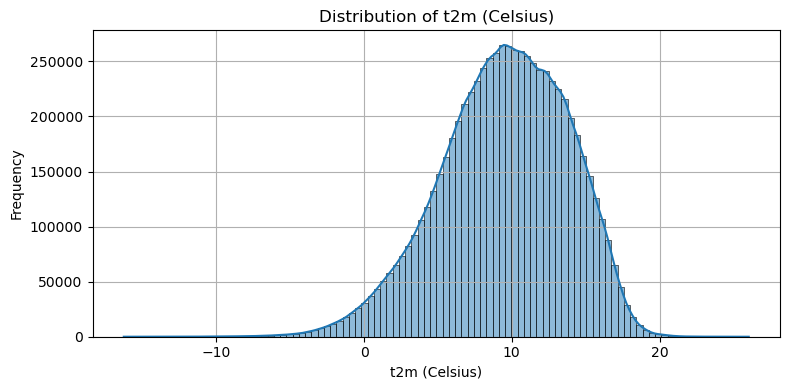

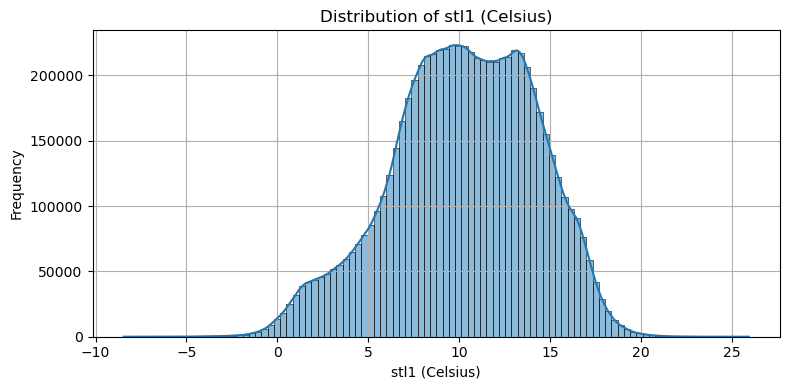

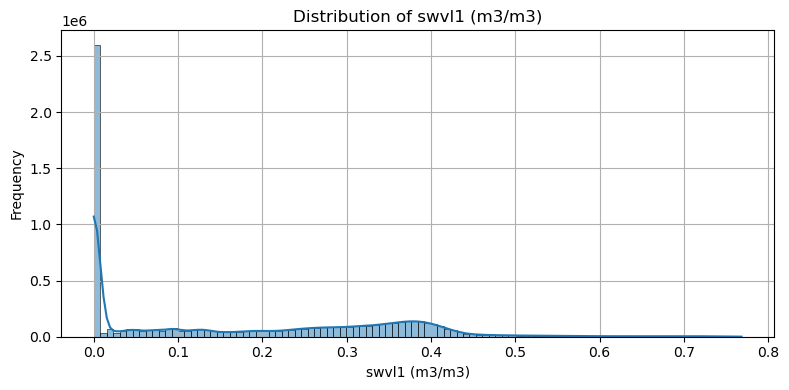

In [112]:
# Check distribution of each variable

# Custom titles for all variables
custom_titles = {
    't2m': 't2m (Celsius)',
    'stl1': 'stl1 (Celsius)',
    'swvl1': 'swvl1 (m3/m3)'
}

# Flatten and plot distributions
for var in variables:
    data = soil_ds[var].values.flatten()
    data = data[~np.isnan(data)]  # Remove NaNs

    plt.figure(figsize=(8, 4))
    sns.histplot(data, bins=100, kde=True)
    
    title = custom_titles[var]
    plt.title(f"Distribution of {title}")
    plt.xlabel(title)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

The negative values in t2m and stl1 was caused by the conversion from Kelvin to Celcius. The negative values in swvl1 needs to be investigated further. Since negative values are not allowed in swvl1, and the distribution is skewed, imputing these negative values with median would be the best approach as it is robust to skewness and outliers (unlike the mean).

In [114]:
# Get valid (non-negative) swvl1 values
valid_swvl1 = soil_ds['swvl1'].where(soil_ds['swvl1'] >= 0)
median_swvl1 = float(valid_swvl1.median().values)

# Replace negative values with the median
soil_ds['swvl1'] = soil_ds['swvl1'].where(soil_ds['swvl1'] >= 0, other=median_swvl1)

In [115]:
# Check how many negatives remain
num_neg_after = (soil_ds['swvl1'] < 0).sum().item()
print(f"Negative swvl1 values remaining: {num_neg_after}")

Negative swvl1 values remaining: 0


In [116]:
# Save the preprocessed dataset
soil_ds.to_netcdf("preprocessed_soil_ds.nc")

##### Step 3: EDA

##### 3a. Summary Statistics

In [118]:
# Summary statistics
summary_stats = {}
for var in soil_ds.data_vars:
    data = soil_ds[var].values.flatten()  # Flatten to a 1D array
    stats = {
        "count": len(data),
        "mean": float(pd.Series(data).mean()),
        "std": float(pd.Series(data).std()),
        "min": float(pd.Series(data).min()),
        "25%": float(pd.Series(data).quantile(0.25)),
        "50% (median)": float(pd.Series(data).median()),
        "75%": float(pd.Series(data).quantile(0.75)),
        "max": float(pd.Series(data).max()),
    }
    summary_stats[var] = stats

# Convert to DataFrame
summary_stats_df = pd.DataFrame(summary_stats).round(3)

# Display
display(summary_stats_df)

,t2m,stl1,swvl1
count,7037160.000,7037160.000,7037160.000
mean,9.489,10.229,0.218
std,4.289,3.946,0.153
min,-16.266,-8.449,0.000
25%,6.675,7.616,0.074
50% (median),9.734,10.394,0.234
75%,12.701,13.220,0.335
max,26.039,25.942,0.768


- The average air temperature (t2m) is 9.49°C, with a range from -16.27°C to 26.04°C, indicating typical UK seasonal variation but also some extreme cold events.
- Soil temperature (stl1) follows a similar pattern with a mean of 10.23°C, ranging from -8.45°C to 25.94°C, and slightly less variability than air temperature.
- Soil moisture (swvl1) shows a right-skewed distribution, with values ranging from 0.0 to 0.768 m³/m³ and a median of 0.234 m³/m³. While 0.768 is high, it could still be realistic under saturated soil conditions, especially in clay-rich regions.

##### 3b. t2m Trend

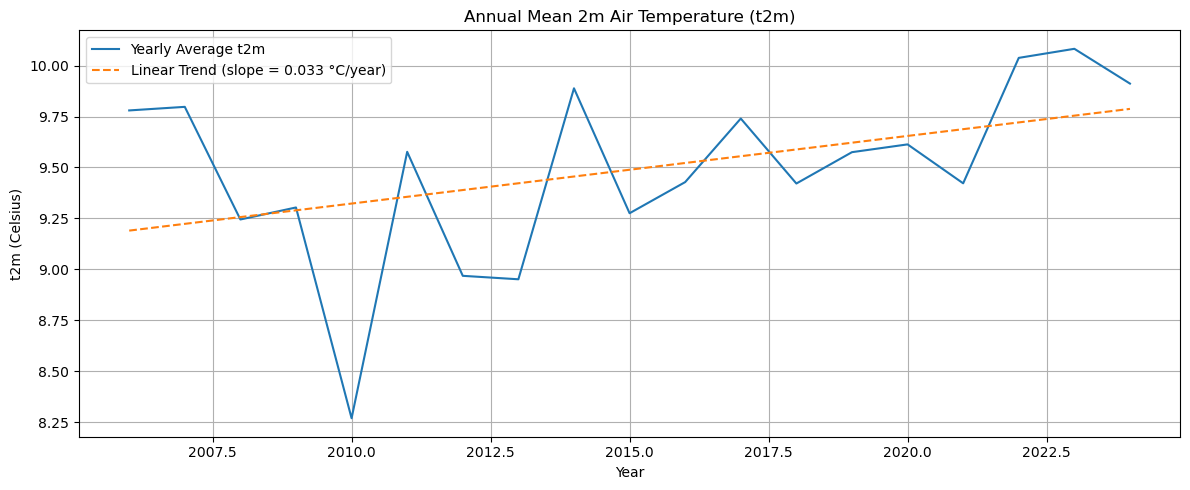

In [119]:
from scipy.stats import linregress

# Extract t2m and convert to DataFrame
t2m_df = soil_ds['t2m'].to_dataframe().reset_index()

# Extract year from datetime
t2m_df['year'] = pd.to_datetime(t2m_df['time']).dt.year

# Group by year and compute annual mean over all locations
annual_means = t2m_df.groupby("year")["t2m"].mean().reset_index()

# Linear regression on the trend
slope, intercept, r_value, p_value, std_err = linregress(annual_means["year"], annual_means["t2m"])
trend_line = intercept + slope * annual_means["year"]

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(annual_means["year"], annual_means["t2m"], label="Yearly Average t2m")
plt.plot(annual_means["year"], trend_line, linestyle="--",
         label=f"Linear Trend (slope = {slope:.3f} °C/year)")
plt.title("Annual Mean 2m Air Temperature (t2m)")
plt.xlabel("Year")
plt.ylabel("t2m (Celsius)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The air temperature trend showcases an increase with a slope 0.033 Celcius per year, similar to the temperature trend from the provided dataset in file 02_EDA.ipynb with slope coefficient 0.036 per year.

##### 3c. stl1 Trend

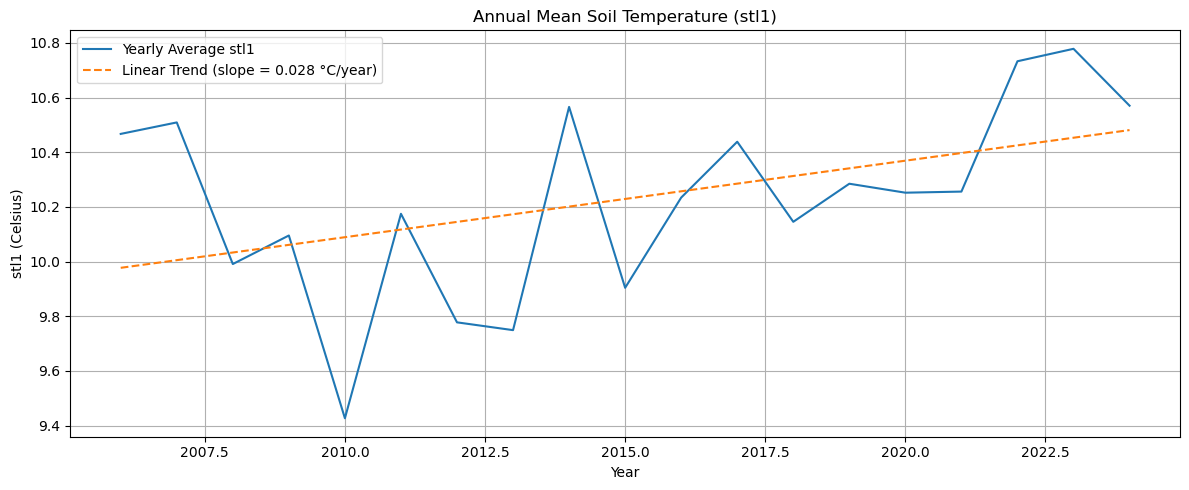

In [121]:
# Extract stl1 and convert to DataFrame
stl1_df = soil_ds['stl1'].to_dataframe().reset_index()

# Extract year from datetime
stl1_df['year'] = pd.to_datetime(stl1_df['time']).dt.year

# Group by year and compute annual mean over all locations
annual_means = stl1_df.groupby("year")["stl1"].mean().reset_index()

# Linear regression on the trend
slope, intercept, r_value, p_value, std_err = linregress(annual_means["year"], annual_means["stl1"])
trend_line = intercept + slope * annual_means["year"]

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(annual_means["year"], annual_means["stl1"], label="Yearly Average stl1")
plt.plot(annual_means["year"], trend_line, linestyle="--",
         label=f"Linear Trend (slope = {slope:.3f} °C/year)")
plt.title("Annual Mean Soil Temperature (stl1)")
plt.xlabel("Year")
plt.ylabel("stl1 (Celsius)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The soil temperature trend showcases an increase as well but with a rate slower than the air temperature (slope 0.028 Celcius per year). This makes sense because it has a higher heat capacity, especially when moist, requiring more energy to heat up. Surface layers act as insulation, and much of the sun’s energy goes into evaporation rather than heating. Unlike air, which responds quickly to solar radiation, soil warms through slower conduction and shows delayed temperature peaks due to daily and seasonal lag (Lin et al., 2010).

##### 3d. swvl1 Trend

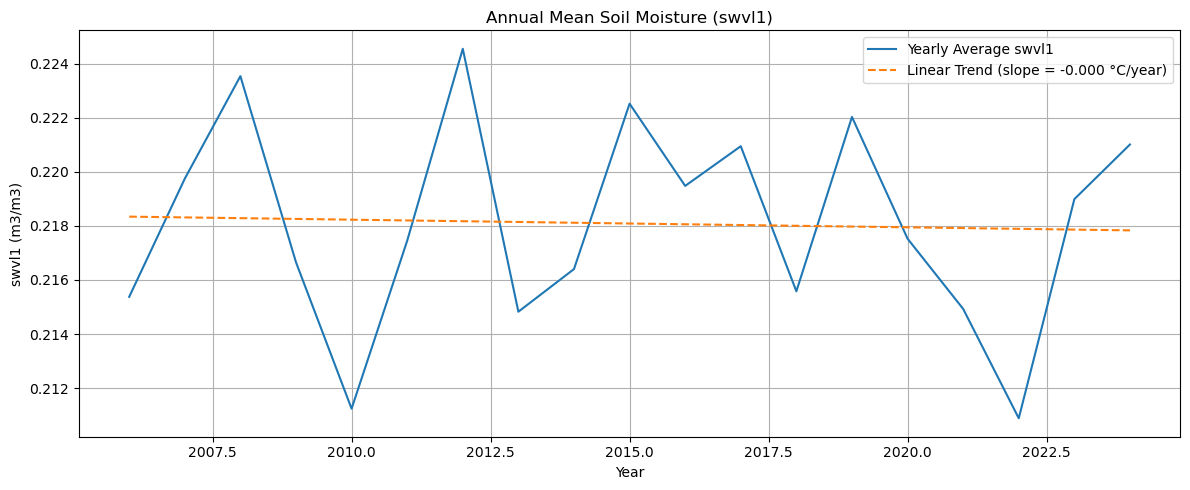

In [123]:
# Extract stl1 and convert to DataFrame
swvl1_df = soil_ds['swvl1'].to_dataframe().reset_index()

# Extract year from datetime
swvl1_df['year'] = pd.to_datetime(swvl1_df['time']).dt.year

# Group by year and compute annual mean over all locations
annual_means = swvl1_df.groupby("year")["swvl1"].mean().reset_index()

# Linear regression on the trend
slope, intercept, r_value, p_value, std_err = linregress(annual_means["year"], annual_means["swvl1"])
trend_line = intercept + slope * annual_means["year"]

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(annual_means["year"], annual_means["swvl1"], label="Yearly Average swvl1")
plt.plot(annual_means["year"], trend_line, linestyle="--",
         label=f"Linear Trend (slope = {slope:.3f} °C/year)")
plt.title("Annual Mean Soil Moisture (swvl1)")
plt.xlabel("Year")
plt.ylabel("swvl1 (m3/m3)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### 3e. Relationship Between Variables

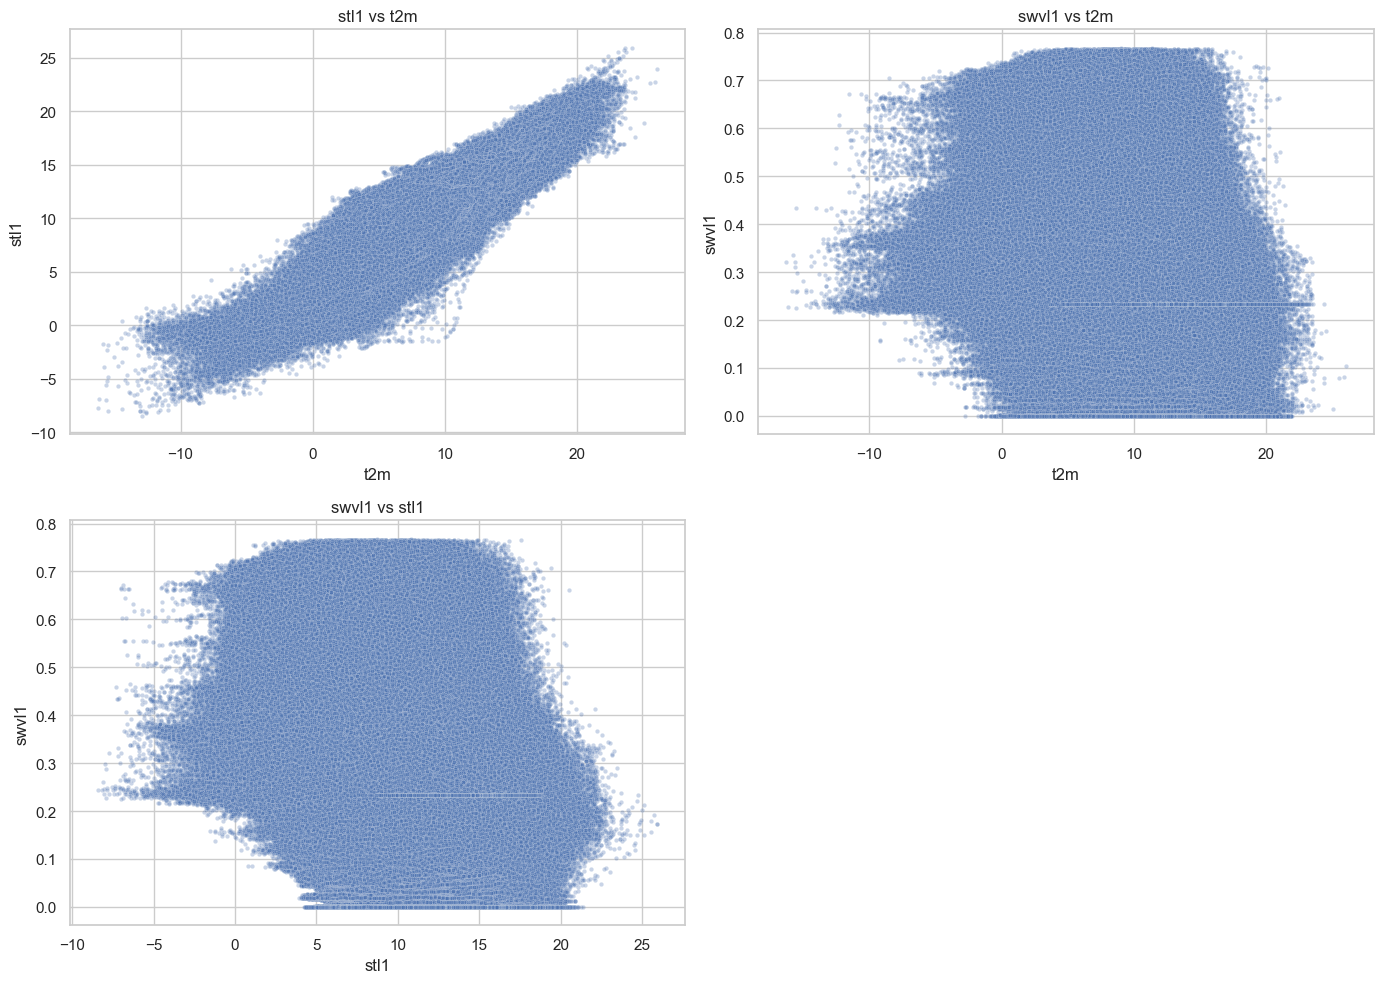

In [124]:
# Extract variables and flatten into a DataFrame
variables = ['t2m', 'stl1', 'swvl1']
df = soil_ds[variables].to_dataframe().dropna().reset_index()

# Set up plot style
sns.set(style="whitegrid")
num_vars = len(variables)

# Set up plot grid
plot_pairs = [('t2m', 'stl1'), ('t2m', 'swvl1'), ('stl1', 'swvl1')]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Create scatter plots
for i, (x_var, y_var) in enumerate(plot_pairs):
    ax = axes[i]
    sns.scatterplot(data=df, x=x_var, y=y_var, ax=ax, alpha=0.3, s=10)
    ax.set_xlabel(f"{x_var}")
    ax.set_ylabel(f"{y_var}")
    ax.set_title(f"{y_var} vs {x_var}")

# Remove any unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

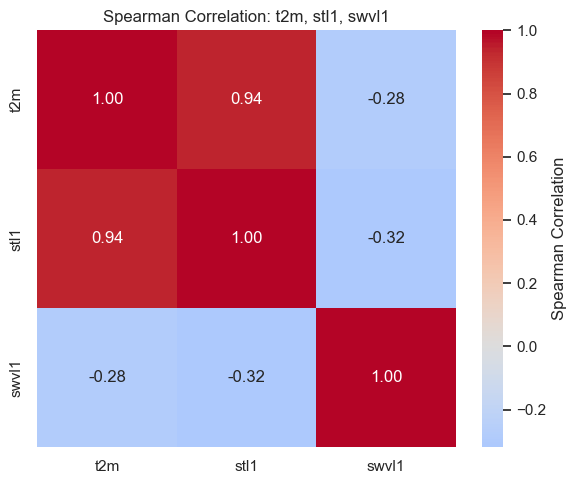

In [128]:
# Compute Spearman correlation matrix (spatial factors ignored / all locations averaged)

# Extract variables and drop NaNs
variables = ['t2m', 'stl1', 'swvl1']
df = soil_ds[variables].to_dataframe().dropna()

# Compute Spearman correlation
spearman_corr = df.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"label": "Spearman Correlation"})
plt.title("Spearman Correlation: t2m, stl1, swvl1")
plt.tight_layout()
plt.show()

From the above correlation matrix, we can see that air temperature (t2m) strongly correlates with soil temperature (stl1) (0.94), but negatively correlates with soil moisture (swvl1)(-0.28, moderate). On the other hand, soil temperature has a stronger moderate-negative correlation with soil moisture (-0.32) compared to air temperature.

In summary, soil moisture (swvl1) tends to decrease with rising temperature (t2m), but the relationship is more mediated through soil temperature (stl1) than directly through air temperature.

This is because soil moisture responds to evaporation, which is driven by soil temperature, solar radiation, and surface conditions. Air temperature is more volatile and might not reflect ground-level thermal dynamics as directly.

##### So, what's next?

- The current soil moisture (swvl1) from 2006 to 2024, showing values that generally range between 0.21 and 0.22 m³/m³. The linear trend line has a slope close to zero, but with decreasing trend.
- The mean soil moisture (~0.218 m³/m³) lies above the wilting point (typically around 0.1 m³/m³), meaning the soil retains sufficient water to support plant life. However, it remains below the field capacity (commonly around 0.3–0.4 m³/m³ for loamy soils in the UK), which is the optimal level for water availability. This suggests that the soil moisture level is moderate—neither critically low nor saturated—which is typical of well-drained agricultural soils, particularly during drier periods.
- If the temperature keeps rising in the future, the soil moisture (swvl1) continues to decline and might approach 0.1 m³/m³ or below, it signals a transition toward increasingly dry and potentially harmful soil conditions.
- To do: add projected temperature and make a projection of soil moisture from 2025-2080

Soil moisture values benchmark:
- Soil moisture values around 0.3–0.4 m³/m³ typically indicate loamy soils at field capacity, which is ideal for crop growth and a healthy balance in the water cycle.
- A drop to around 0.2 m³/m³ suggests that the soil is below field capacity, where plants may begin to experience water stress, especially during dry periods.
- Levels near 0.1 m³/m³, the soil is approaching the wilting point, a threshold below which plants can no longer extract water effectively.
- Should it fall below 0.1, the soil becomes very dry, posing serious risks such as drought stress, crop failure, and land degradation.

A sustained decrease in soil moisture can lead to widespread consequences. Agriculturally, it may result in reduced crop yields and increased dependence on irrigation. From a hydrological perspective, it can reduce groundwater recharge and disrupt the balance of water systems. Ecologically, the drying of soil may trigger vegetation loss, soil compaction, and heightened erosion. Moreover, a drying trend in soils can contribute to a broader climate feedback loop, where reduced soil moisture amplifies local heat extremes, further intensifying drought conditions and ecological vulnerability.